# 3 Exploratory Data Analysis (EDA)

**Nguồn**: query trực tiếp từ Postgres DW (`fact_salary` JOIN tất cả `dim_*`) — chính là góc nhìn Power BI sẽ có.

**Mục tiêu**: khám phá tương quan giữa các **chiều** (categorical / ordinal) với **chỉ số đo lường** chính (`salary_in_usd`).

## Cách trình bày

Mỗi section dưới đây có 3 phần đánh giá visual:

- **Câu hỏi mục tiêu** — section trả lời câu gì.
- **Công cụ + lý do** — chart type / metric, vì sao chọn so với alternatives.
- **Cách đọc + hạn chế** — interpret kết quả, caveat cần biết.

## Pyramid analysis từ rộng đến hẹp

| # | Section | Tầng phân tích | Output |
|---|---|---|---|
| 1 | Load DW | (chuẩn bị) | flat DataFrame |
| 2 | Distribution | Univariate measure | salary shape + transform decision |
| 3 | Category balance | **Bias check trên dim** | top_share, imbalance, entropy |
| 4 | Per-dim summary | Univariate dim × measure | group stats + boxplots |
| 5 | Effect-size ranking | Cross-dim ranking | quantify which dim matters most |
| 5b | Tukey HSD | Post-hoc on top dim | pairwise differences |
| 6 | Cross-dim heatmap | Bivariate interaction | mean × interaction view |
| 7 | Year trend | Time series | growth across years × seniority |
| 8 | Geographic | Country deep-dive | top-N median salary |
| 9 | Cross-border | Business slice | %, work_setting breakdown |
| 10 | Numeric corr | Numeric variables | Pearson vs Spearman |
| — | Takeaways + Gaps | Summary | conclusions + enhancements |

Mỗi tầng chỉ áp dụng khi tầng dưới hợp lệ — vd. không có ích chạy ANOVA nếu measure phân phối quá tệ hoặc group quá lệch.

In [1]:
import os, sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.warehouse import pg_connection

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100


def query_df(sql, conn=None):
    """Run SQL and return a DataFrame (avoids the SQLAlchemy/pandas warning)."""
    def _run(c):
        with c.cursor() as cur:
            cur.execute(sql)
            cols = [d[0] for d in cur.description]
            rows = cur.fetchall()
        return pd.DataFrame(rows, columns=cols)
    if conn is None:
        with pg_connection() as c:
            return _run(c)
    return _run(conn)

## 1. Load denormalized dataset từ DW

**Câu hỏi mục tiêu**: build 1 flat DataFrame dùng chung cho mọi analysis phía dưới.

**Công cụ**: SQL join `fact_salary` ⋈ 11 dim tables. `dim_location` join 2 lần (employee + company).

**Lý do**:
- Single query → ít round-trip, dim values đã được normalize ở stage transform → không cần process trong pandas.
- Materialize ra DataFrame thay vì gọi DW liên tục từng cell → notebook reproducible kể cả khi DB tạm offline.

**Cách đọc**: shape `(5500, 18)` + `missing = None` → DW state sạch, có thể tin downstream.

In [2]:
SQL = '''
SELECT
    d.year                   AS work_year,
    j.job_title              AS job_title,
    jc.job_category_name     AS job_category,
    e.level_name             AS experience_level,
    e.rank_order             AS experience_rank,
    et.type_name             AS employment_type,
    ws.setting_name          AS work_setting,
    cs.size_code             AS company_size,
    cs.size_desc             AS company_size_desc,
    c.currency_code          AS salary_currency,
    lr.country               AS employee_country,
    rr.region_name           AS employee_region,
    ce.continent_name        AS employee_continent,
    lc.country               AS company_country,
    rc.region_name           AS company_region,
    co.continent_name        AS company_continent,
    f.salary                 AS salary,
    f.salary_in_usd          AS salary_in_usd
FROM fact_salary f
JOIN dim_date d             ON d.date_id   = f.date_id
JOIN dim_job j              ON j.job_id    = f.job_id
JOIN dim_job_category jc    ON jc.job_category_id = j.job_category_id
JOIN dim_experience e       ON e.experience_id    = f.experience_id
JOIN dim_employment_type et ON et.employment_type_id = f.employment_type_id
JOIN dim_work_setting ws    ON ws.work_setting_id = f.work_setting_id
JOIN dim_company_size cs    ON cs.company_size_id = f.company_size_id
JOIN dim_currency c         ON c.currency_id      = f.currency_id
JOIN dim_location lr        ON lr.location_id     = f.employee_location_id
JOIN dim_region rr          ON rr.region_id       = lr.region_id
JOIN dim_continent ce       ON ce.continent_id    = rr.continent_id
JOIN dim_location lc        ON lc.location_id     = f.company_location_id
JOIN dim_region rc          ON rc.region_id       = lc.region_id
JOIN dim_continent co       ON co.continent_id    = rc.continent_id
'''
df = query_df(SQL)
print('shape:', df.shape)
df.head()

shape: (5500, 18)


,work_year,job_title,job_category,experience_level,experience_rank,employment_type,work_setting,company_size,company_size_desc,salary_currency,employee_country,employee_region,employee_continent,company_country,company_region,company_continent,salary,salary_in_usd
0,2023,Data DevOps Engineer,Data Engineering,Mid-level,2,Full-time,Hybrid,L,Large,EUR,Germany,Western Europe,Europe,Germany,Western Europe,Europe,88000,95012
1,2023,Data Architect,Data Architecture and Modeling,Senior,3,Full-time,In-person,M,Medium,USD,United States,Northern America,North America,United States,Northern America,North America,186000,186000
2,2023,Data Architect,Data Architecture and Modeling,Senior,3,Full-time,In-person,M,Medium,USD,United States,Northern America,North America,United States,Northern America,North America,81800,81800
3,2023,Data Scientist,Data Science and Research,Senior,3,Full-time,In-person,M,Medium,USD,United States,Northern America,North America,United States,Northern America,North America,212000,212000
4,2023,Data Scientist,Data Science and Research,Senior,3,Full-time,In-person,M,Medium,USD,United States,Northern America,North America,United States,Northern America,North America,93300,93300


In [3]:
print('dtypes:'); print(df.dtypes)
missing = df.isna().sum()
print('\nmissing:'); print(missing[missing > 0] if (missing > 0).any() else 'None')
print('\nsalary_in_usd describe:')
df['salary_in_usd'].describe().to_frame().T

dtypes:
work_year              int64
job_title             object
job_category          object
experience_level      object
experience_rank        int64
employment_type       object
work_setting          object
company_size          object
company_size_desc     object
salary_currency       object
employee_country      object
employee_region       object
employee_continent    object
company_country       object
company_region        object
company_continent     object
salary                 int64
salary_in_usd          int64
dtype: object

missing:
None

salary_in_usd describe:


,count,mean,std,min,25%,50%,75%,max
salary_in_usd,5500.0,146155.524909,66307.184131,15000.0,99000.0,140000.0,185900.0,430967.0


## 2. Phân phối đơn biến của measure

**Câu hỏi mục tiêu**: biến `salary_in_usd` có "khỏe" không? Có cần transform (log) trước khi vào phân tích sâu không?

**Công cụ**: 3 visuals + 2 chỉ số định lượng đặt cạnh nhau.

| Tool | Vai trò |
|---|---|
| Histogram linear | Shape thô: unimodal/multimodal, tail dài không |
| Histogram log10 | Test tính log-normal — money/income/population thường log-normal |
| Boxplot | 5-number summary + outlier flags |
| Skewness | Định lượng độ lệch (|skew|>1 = heavy, 0.5–1 = moderate) |
| Kurtosis | Độ "nhọn" của đỉnh + nặng tail |

**Lý do chọn**:
- Linear + log đặt cạnh nhau → quyết định **có cần log transform** ngay bằng mắt: nếu log-hist gần normal hơn nhiều → nên log.
- Boxplot bổ sung số liệu (whiskers, outlier dots) — phù hợp khi muốn show trong dashboard.
- Skew + kurt là **summary statistics**, đỡ phải đoán bằng mắt.

**Lưu ý không dùng**: Shapiro-Wilk test. Với n=5500, Shapiro luôn reject normality dù sai lệch chỉ một chút — không có giá trị thực tế.

**Cách đọc**: nếu skew > 1 hoặc log-hist nhìn rõ ràng đẹp hơn linear → áp log transform trước. Ngược lại linear scale là đủ.

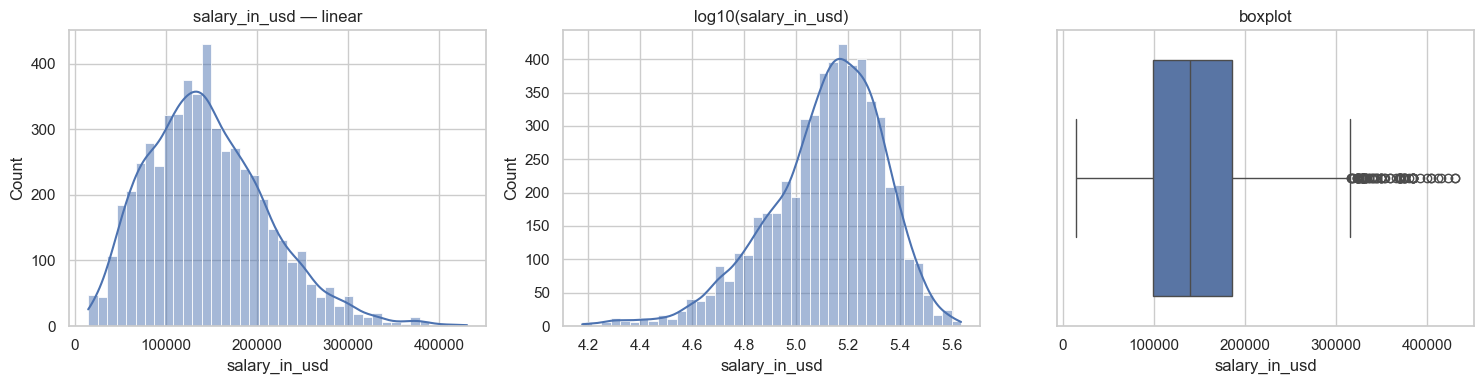

Skewness: 0.651
Kurtosis: 0.512


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['salary_in_usd'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('salary_in_usd — linear')
sns.histplot(np.log10(df['salary_in_usd'].clip(lower=1)), bins=40, kde=True, ax=axes[1])
axes[1].set_title('log10(salary_in_usd)')
sns.boxplot(x=df['salary_in_usd'], ax=axes[2])
axes[2].set_title('boxplot')
plt.tight_layout(); plt.show()

print(f"Skewness: {df['salary_in_usd'].skew():.3f}")
print(f"Kurtosis: {df['salary_in_usd'].kurt():.3f}")

## 3. Category balance — kiểm tra bias

**Câu hỏi mục tiêu**: các chiều có cân bằng giữa các group không? Chiều nào bị dominated bởi 1 majority class?

**Vì sao cần check trước per-dim analysis**:
- Group `n < 30` → mean/median unstable, kết luận per-dim (mục 4) không đáng tin với group đó.
- ANOVA giả định equal variance / balanced groups — fail nặng nề khi imbalance lớn → F-stat lệch.
- ML model downstream sẽ học bias từ majority class nếu không stratify.
- Insight EDA có thể chỉ phản ánh majority class chứ không phải bức tranh chung.

**Công cụ**: 2 view bổ trợ nhau

| View | Hiển thị | Vai trò |
|---|---|---|
| Bảng metrics | n_groups, top_share %, imbalance_ratio, entropy_norm, min_group_n | quantify mức bias mỗi chiều |
| Bar grid | count per group cho chiều low-cardinality (≤10 groups) | thấy hình dạng phân phối |

**3 metric chính trong bảng**:

| Metric | Ý nghĩa | Threshold cảnh báo |
|---|---|---|
| `top_share_%` | % rows thuộc majority class | > 80% → dominant |
| `imbalance_ratio` | count(max) / count(min) | > 100× → severely imbalanced |
| `entropy_norm` | H / log(k), thang 0–1 | < 0.5 → phân phối lệch nặng (0 = 1 group, 1 = đều) |

**Cách đọc**:
- 3 metric phải đọc cùng nhau — entropy không phân biệt "1 majority lớn" vs "2 majority + many tiny", phải xem `top_share` để hiểu shape.
- Bảng được color-coded: đỏ ở cột bias (cao = xấu), xanh ở entropy (cao = tốt).
- Bar grid chỉ vẽ chiều ≤10 groups; chiều cardinality cao xem qua `top-10 share` print phía dưới.

**Hạn chế**:
- Imbalance ≠ "data sai". Có thể phản ánh đúng population thực (vd. US dominant trong tech salary).
- Chỉ check **structural imbalance** trong dataset; không phát hiện **sampling bias** (dataset có miss systematic country/role nào không) — đó là vấn đề upstream của Kaggle source.

In [5]:
from scipy.stats import entropy as shannon_entropy


def balance_metrics(df, dim):
    vc = df[dim].value_counts()
    n_total = len(df)
    k = len(vc)
    probs = (vc / n_total).values
    h_norm = shannon_entropy(probs) / np.log(k) if k > 1 else 0.0
    return {
        'dim': dim,
        'n_groups': k,
        'top_class': str(vc.index[0])[:28],
        'top_share_%': round(vc.iloc[0] / n_total * 100, 1),
        'min_group_n': int(vc.iloc[-1]),
        'imbalance_ratio': round(vc.iloc[0] / vc.iloc[-1], 1),
        'entropy_norm': round(h_norm, 3),
    }


BIAS_DIMS = [
    'work_year', 'experience_level', 'employment_type', 'work_setting',
    'company_size', 'salary_currency', 'job_category', 'job_title',
    'employee_country', 'company_country', 'employee_continent', 'company_continent',
]

balance = pd.DataFrame([balance_metrics(df, d) for d in BIAS_DIMS]).sort_values('entropy_norm')
(balance.style
        .background_gradient(subset=['top_share_%', 'imbalance_ratio'], cmap='Reds')
        .background_gradient(subset=['entropy_norm'], cmap='Greens'))

,dim,n_groups,top_class,top_share_%,min_group_n,imbalance_ratio,entropy_norm
2,employment_type,4,Full-time,99.200000,11,495.900000,0.041000
5,salary_currency,11,USD,88.700000,3,1627.000000,0.202000
9,company_country,70,United States,80.700000,1,4441.000000,0.233000
8,employee_country,83,United States,79.900000,1,4395.000000,0.239000
11,company_continent,6,North America,84.700000,20,233.000000,0.291000
10,employee_continent,6,North America,83.900000,22,209.700000,0.311000
4,company_size,3,M,88.500000,151,32.200000,0.383000
0,work_year,4,2023,74.700000,70,58.700000,0.517000
7,job_title,125,Data Engineer,20.900000,1,1147.000000,0.602000
1,experience_level,4,Senior,66.200000,218,16.700000,0.668000


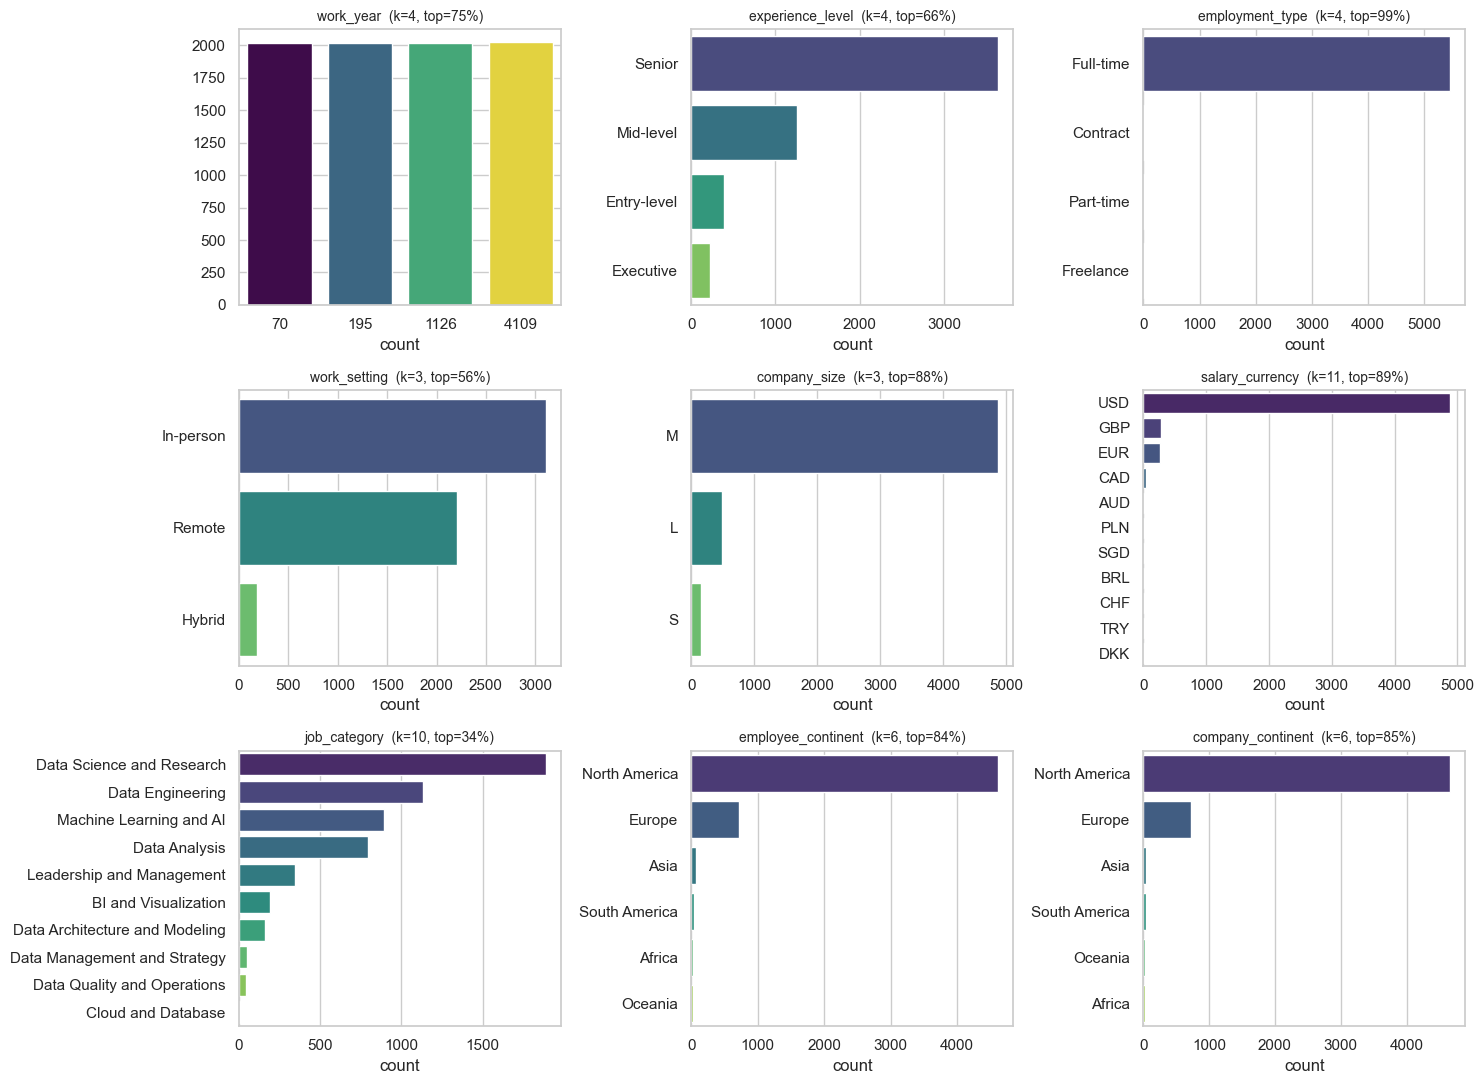

High-cardinality dims — top-10 share check:
  job_title              top 10 / 125 groups → 78% of all rows
  employee_country       top 10 / 83 groups → 95% of all rows
  company_country        top 10 / 70 groups → 96% of all rows


In [17]:
LOW_CARD = ['work_year', 'experience_level', 'employment_type', 'work_setting',
            'company_size', 'salary_currency', 'job_category',
            'employee_continent', 'company_continent']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, dim in zip(axes.flat, LOW_CARD):
    vc = df[dim].value_counts()
    top_pct = vc.iloc[0] / len(df) * 100
    sns.barplot(x=vc.values, y=vc.index, hue=vc.index, ax=ax,
                palette='viridis', legend=False)
    ax.set_title(f'{dim}  (k={len(vc)}, top={top_pct:.0f}%)', fontsize=10)
    ax.set_xlabel('count'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

print('High-cardinality dims — top-10 share check:')
for dim in ['job_title', 'employee_country', 'company_country']:
    vc = df[dim].value_counts()
    top10_share = vc.head(10).sum() / len(df) * 100
    print(f'  {dim:<22} top 10 / {len(vc)} groups → {top10_share:.0f}% of all rows')

## 4. Salary theo từng chiều (univariate per dim)

**Câu hỏi mục tiêu**: salary của mỗi group trong từng chiều phân bố ra sao? Group nào trả cao nhất / thấp nhất?

**Công cụ**: group statistics table + horizontal boxplot, lặp qua 6 chiều chính.

**Lý do chọn**:
- **Sort theo `median`, không phải `mean`** — salary right-skewed (mục 2) nên mean bị outlier kéo lệch. Median robust hơn cho ranking.
- **Horizontal boxplot** — chiều như `job_category` có 10 groups, đặt tên group trên trục Y dễ scan hơn xoay nghiêng dưới trục X.
- **5-number summary table cạnh chart** — cho người đọc cả picture trực quan và con số chính xác (n, p25, p75).
- **Order tùy chiều**: ordinal (`experience_level`, `company_size`) giữ thứ tự logic; categorical thì auto-sort theo median.

**Liên kết với mục 3 (bias)**: kết quả trong section này cần đọc cùng `n` của mỗi group. Group có `n` rất nhỏ (vd. work_setting=Hybrid với n=191 vs In-person n=3107) → median của Hybrid kém ổn định hơn.

**Hạn chế**:
- Boxplot **ẩn modality**. Nếu một group thực sự có 2 đỉnh salary (vd. từ 2 vùng địa lý khác nhau) thì boxplot không thấy. Trường hợp nghi ngờ nên dùng violin / KDE.
- Whiskers theo Tukey rule (1.5×IQR) → một số outlier hợp lệ vẫn bị flag.


=== experience_level ===


,n,mean,median,std,p25,p75
experience_level,,,,,,
Executive,218,187484.0,183360.0,69637.0,135086.0,230000.0
Senior,3640,160539.0,153575.0,62567.0,116225.0,198800.0
Mid-level,1250,116228.0,106600.0,58269.0,73511.5,149575.0
Entry-level,392,85042.0,75000.0,48764.0,50000.0,112000.0


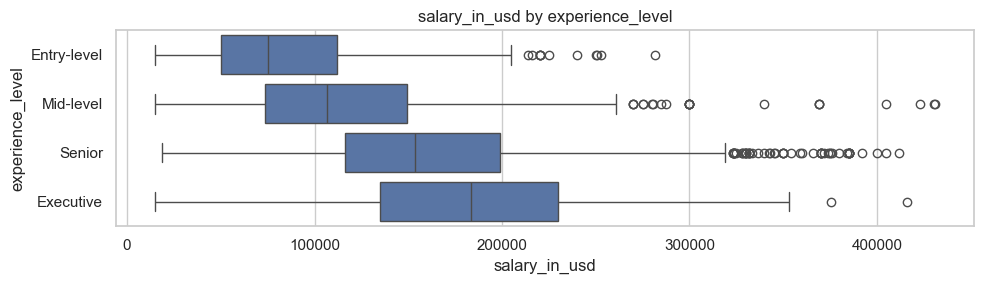


=== employment_type ===


,n,mean,median,std,p25,p75
employment_type,,,,,,
Full-time,5455,146686.0,140000.0,65933.0,100000.0,186000.0
Contract,19,117109.0,90000.0,107696.0,47376.5,111769.5
Part-time,15,57866.0,52533.0,40967.0,23442.5,84870.5
Freelance,11,53869.0,50000.0,26443.0,40777.5,60000.0


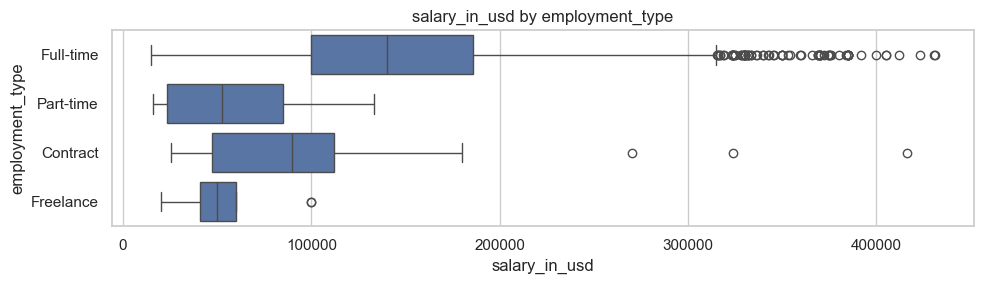


=== work_setting ===


,n,mean,median,std,p25,p75
work_setting,,,,,,
In-person,3105,152937.0,144400.0,66402.0,105000.0,192351.0
Remote,2209,141430.0,136600.0,63692.0,94035.0,182200.0
Hybrid,186,89070.0,74065.0,63061.0,50000.0,109756.0


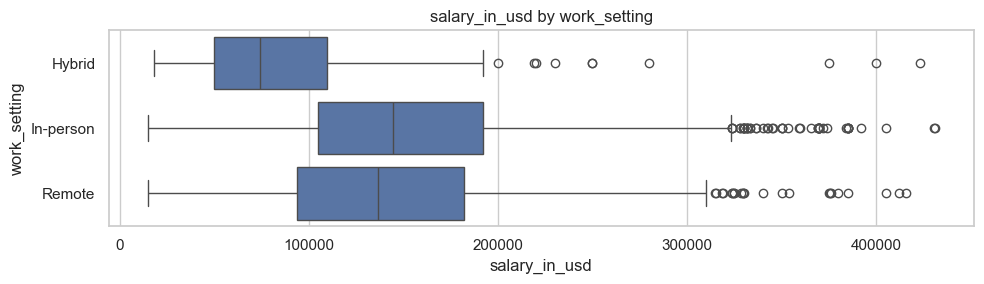


=== company_size ===


,n,mean,median,std,p25,p75
company_size,,,,,,
M,4865,149921.0,143000.0,64423.0,104000.0,189650.0
L,484,125731.0,111800.0,74906.0,70000.0,170000.0
S,151,90305.0,76833.0,59874.0,50000.0,115111.0


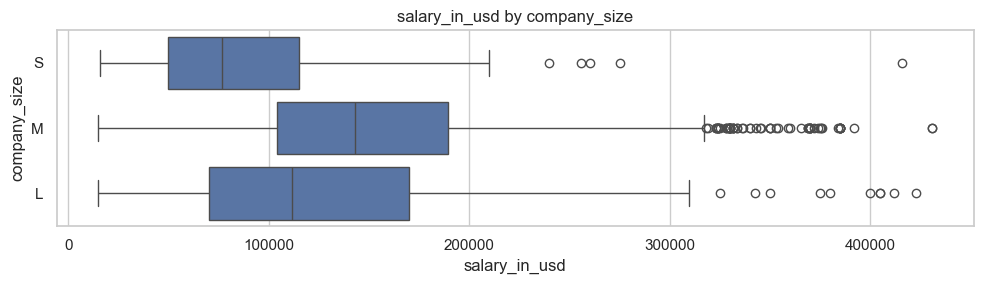


=== job_category ===


,n,mean,median,std,p25,p75
job_category,,,,,,
Machine Learning and AI,895,170986.0,169000.0,74625.0,121494.00,218647.5
Cloud and Database,5,155000.0,160000.0,28723.0,140000.00,170000.0
Data Science and Research,1888,155131.0,150000.0,65527.0,110027.75,195800.0
Data Architecture and Modeling,160,156042.0,150000.0,61294.0,110552.00,191800.0
Leadership and Management,343,149444.0,140000.0,63711.0,109140.00,182500.0
Data Engineering,1133,142775.0,135000.0,61888.0,97000.00,182750.0
BI and Visualization,189,129028.0,125009.0,47618.0,97000.00,160000.0
Data Analysis,792,107023.0,100697.5,49405.0,70000.00,134200.0
Data Management and Strategy,50,107103.0,91796.5,46609.0,71625.00,128250.0


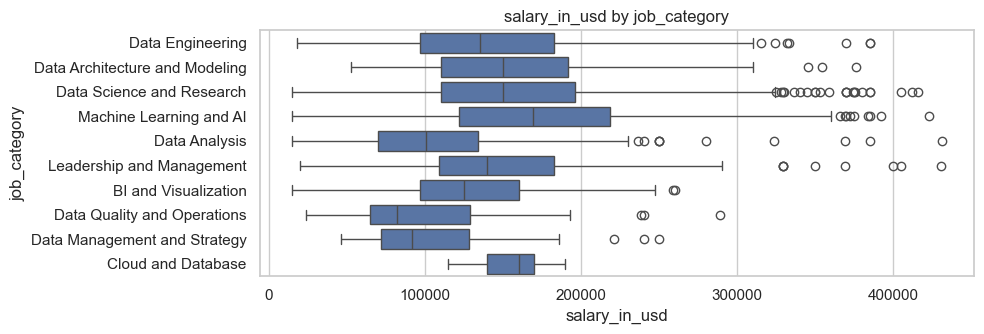


=== work_year ===


,n,mean,median,std,p25,p75
work_year,,,,,,
2023,4109,152431.0,145000.0,66195.0,105000.00,192400.0
2022,1126,133004.0,130000.0,60562.0,86669.75,172200.0
2021,195,106085.0,90000.0,66942.0,60000.00,148500.0
2020,70,100963.0,86000.0,73099.0,50465.25,117776.0


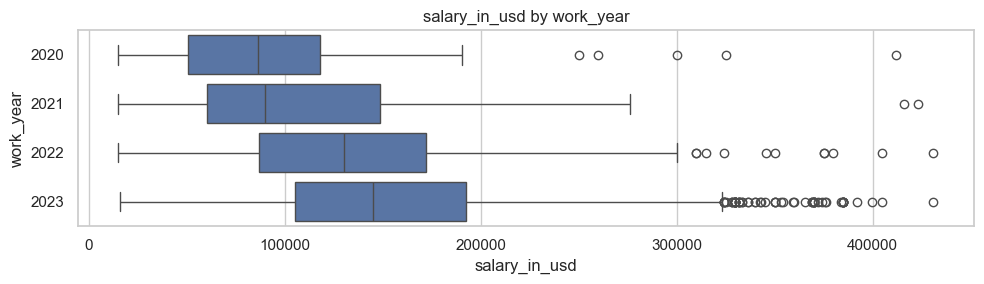

In [7]:
EXP_ORDER  = ['Entry-level', 'Mid-level', 'Senior', 'Executive']
SIZE_ORDER = ['S', 'M', 'L']

DIM_VS_MEASURE = [
    ('experience_level', EXP_ORDER),
    ('employment_type',  None),
    ('work_setting',     None),
    ('company_size',     SIZE_ORDER),
    ('job_category',     None),
    ('work_year',        None),
]

def summarize(df, dim):
    g = df.groupby(dim, observed=True)['salary_in_usd']
    return pd.DataFrame({
        'n':      g.size(),
        'mean':   g.mean().round(0),
        'median': g.median(),
        'std':    g.std().round(0),
        'p25':    g.quantile(0.25),
        'p75':    g.quantile(0.75),
    }).sort_values('median', ascending=False)

for dim, order in DIM_VS_MEASURE:
    print(f'\n=== {dim} ===')
    display(summarize(df, dim))
    plt.figure(figsize=(10, max(3, 0.35 * df[dim].nunique())))
    sns.boxplot(data=df, y=dim, x='salary_in_usd', order=order, orient='h')
    plt.title(f'salary_in_usd by {dim}')
    plt.tight_layout(); plt.show()

## 5. Effect-size ranking — chiều nào ảnh hưởng salary mạnh nhất

**Câu hỏi mục tiêu**: rank các chiều theo mức ảnh hưởng đến salary để biết feature nào quan trọng cho dashboard / model downstream.

**Công cụ**: 4 metric đặt cạnh nhau, mỗi metric có bias riêng — đọc cùng nhau mới ra picture đúng.

| Metric | Công thức | Ý nghĩa | Bias |
|---|---|---|---|
| **F-stat** | MS_between / MS_within | "Có tín hiệu không?" | Tăng theo cả n và k → khó so sánh giữa dim |
| **F_per_df** | F / (k − 1) | "Separation per group" | Heuristic trực quan để compare chiều có cardinality khác nhau |
| **eta²** | SS_between / SS_total | % variance giải thích được | Inflated theo k — mỗi group thêm 1 df = thêm cơ hội "ăn" variance |
| **omega²** | (SS_b − (k−1)·MS_w) / (SS_total + MS_w) | eta² đã debias | Conservative, **chuẩn nhất để rank** — bảng sort theo omega² |

**Lý do song song 4 metric**: cardinality các chiều rất chênh (`employment_type` 4 groups vs `job_title` 111 groups). Một metric đơn không công bằng:
- Chỉ nhìn `eta²` → kết luận sai "`job_title` mạnh nhất" do high cardinality.
- Chỉ nhìn `F` → cùng bias.
- `omega²` đỡ bias nhưng vẫn ưu ái high-k.
- `F_per_df` cho story sạch: chiều nào có separation per group cao nhất.

**Caveat về multicollinearity**: các chiều địa lý (`employee_country`, `company_country`, `employee_continent`, `company_continent`, `salary_currency`) chồng lấp lẫn nhau — currency là proxy của country. Single-dim ANOVA không tách được; eta²/omega² trên một chiều phản ánh cả phần của các chiều còn lại. Muốn attribute đúng cần multivariate regression hoặc partial eta² trong mô hình OLS.

**Caveat về imbalance (liên kết mục 3)**: chiều `employment_type` có 99% Full-time → ANOVA F-stat không phản ánh "tầm quan trọng thực" mà chỉ phản ánh "không có sample đủ ở 3 group nhỏ để phân biệt". omega² ≈ 0.009 không có nghĩa "không quan trọng" mà nghĩa là "không phân biệt được trong dataset hiện tại".

**Cách đọc bảng**: 2 đáp án bổ trợ —
- "Chiều nào giải thích NHIỀU variance nhất" → top omega² (chiều cardinality cao).
- "Chiều nào có TÍN HIỆU MỖI GROUP SẠCH NHẤT" → top F/df (chiều ordinal / cardinality thấp).

In [8]:
def effect_stats(df, dim, measure='salary_in_usd'):
    groups = [g[measure].values for _, g in df.groupby(dim, observed=True) if len(g) >= 2]
    if len(groups) < 2:
        return None
    f, p = stats.f_oneway(*groups)
    grand = df[measure].mean()
    N = sum(len(g) for g in groups)
    k = len(groups)
    ss_total = ((df[measure] - grand) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    ss_within = ss_total - ss_between
    ms_within = ss_within / (N - k)
    eta2 = ss_between / ss_total
    omega2 = (ss_between - (k - 1) * ms_within) / (ss_total + ms_within)
    return {
        'dim': dim, 'n_groups': k, 'F': f, 'F_per_df': f / (k - 1),
        'p_value': p, 'eta_squared': eta2, 'omega_squared': omega2,
    }

DIMS_TO_RANK = [
    'experience_level', 'job_title', 'job_category', 'employment_type',
    'work_setting', 'company_size', 'salary_currency',
    'employee_country', 'company_country', 'employee_continent', 'company_continent',
    'work_year',
]
ranking = pd.DataFrame([r for r in (effect_stats(df, d) for d in DIMS_TO_RANK) if r])
ranking = ranking.sort_values('omega_squared', ascending=False).reset_index(drop=True)
ranking_display = ranking.assign(
    eta_squared=lambda x: x['eta_squared'].round(4),
    omega_squared=lambda x: x['omega_squared'].round(4),
    F=lambda x: x['F'].round(1),
    F_per_df=lambda x: x['F_per_df'].round(1),
    p_value=lambda x: x['p_value'].map(lambda v: f'{v:.2e}'),
)[['dim', 'n_groups', 'F', 'F_per_df', 'p_value', 'eta_squared', 'omega_squared']]
ranking_display

,dim,n_groups,F,F_per_df,p_value,eta_squared,omega_squared
0,job_title,111,10.8,0.1,1.07e-159,0.1794,0.1626
1,employee_country,55,20.2,0.4,3.25e-174,0.1663,0.1579
2,experience_level,4,332.0,110.7,4.07e-198,0.1534,0.1529
3,employee_continent,6,193.5,38.7,2.11e-190,0.1497,0.1489
4,company_country,48,21.3,0.5,6.31e-163,0.1544,0.1471
5,company_continent,6,174.8,35.0,4.24e-173,0.1372,0.1364
6,salary_currency,11,86.5,8.6,3.41e-166,0.1361,0.1345
7,job_category,10,59.9,6.7,4.14e-105,0.0894,0.0879
8,work_year,4,63.7,21.2,1.71e-40,0.0336,0.0331
9,work_setting,3,93.8,46.9,8.37e-41,0.0330,0.0327


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=ranking, y='dim', x='omega_squared', hue='dim',
            palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Effect size (omega²) — cardinality-adjusted')
axes[0].set_xlabel('omega²')
sns.barplot(data=ranking.sort_values('F_per_df', ascending=False),
            y='dim', x='F_per_df', hue='dim',
            palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Per-group separation (F / df_between)')
axes[1].set_xlabel('F per degree of freedom')
plt.tight_layout(); plt.show()

### 5b. Post-hoc: Tukey HSD trên `experience_level`

**Câu hỏi mục tiêu**: ANOVA chỉ kết luận "ít nhất 1 cặp khác". Tukey HSD trả lời "cặp NÀO khác, khác bao nhiêu, có ý nghĩa không".

**Công cụ**: `scipy.stats.tukey_hsd` — pairwise mean comparison + 95% CI cho từng cặp.

**Lý do chọn Tukey HSD**:
- Naive: chạy 6 t-test cho 6 cặp → **FWER inflation**: P(false positive ≥ 1) ≈ 1 − 0.95⁶ ≈ **26%**.
- Tukey kiểm soát family-wise error rate ở α=0.05 cho **TẤT CẢ pairs đồng thời**, power tốt hơn Bonferroni (Bonferroni quá conservative khi nhiều cặp).
- Phù hợp với biến ordinal: kiểm tra **ladder** (Entry → Mid → Senior → Executive) có monotonic, gap có đều không.

**Lý do chỉ làm trên `experience_level`**:
- 4 groups → 6 pairs, đọc được trong 1 bảng.
- Là chiều ordinal có thứ tự kinh tế rõ → câu hỏi pairwise có ý nghĩa thực.
- Chiều như `job_title` (111 groups) → 6105 pairs, không meaningful.

**Cách đọc output**:
- `mean_diff` = mean(level_A) − mean(level_B), đơn vị USD.
- `p_value` < 0.05 → cặp khác nhau có ý nghĩa.
- `ci_low / ci_high` = 95% CI của difference; CI không chứa 0 cũng tương đương significant.

**Alternative đã cân nhắc**:
- **Bonferroni**: dùng α/k → conservative quá, power kém.
- **Games-Howell**: cho unequal variance — không dùng vì variance ở các experience level khá cân.
- **Dunnett's test**: nếu có 1 reference group cố định (vd. Entry-level). Không hợp vì muốn all-pairs.

In [10]:
exp_groups = [df.loc[df['experience_level'] == lvl, 'salary_in_usd'].values for lvl in EXP_ORDER]
tukey = stats.tukey_hsd(*exp_groups)

pairs = []
for i in range(len(EXP_ORDER)):
    for j in range(i + 1, len(EXP_ORDER)):
        pairs.append({
            'level_A': EXP_ORDER[i],
            'level_B': EXP_ORDER[j],
            'mean_diff': round(float(tukey.statistic[i, j]), 0),
            'p_value':   f'{tukey.pvalue[i, j]:.2e}',
            'ci_low':    round(float(tukey.confidence_interval(0.95).low[i, j]), 0),
            'ci_high':   round(float(tukey.confidence_interval(0.95).high[i, j]), 0),
        })
pd.DataFrame(pairs)

,level_A,level_B,mean_diff,p_value,ci_low,ci_high
0,Entry-level,Mid-level,-31186.0,0.00e+00,-40265.0,-22108.0
1,Entry-level,Senior,-75497.0,0.00e+00,-83834.0,-67161.0
2,Entry-level,Executive,-102442.0,0.00e+00,-115692.0,-89192.0
3,Mid-level,Senior,-44311.0,0.00e+00,-49452.0,-39170.0
4,Mid-level,Executive,-71256.0,0.00e+00,-82766.0,-59745.0
5,Senior,Executive,-26945.0,1.56e-09,-37880.0,-16010.0


## 6. Cross-dimensional heatmap

**Câu hỏi mục tiêu**: hiệu ứng của 1 chiều có CHANGE theo level của chiều khác không? (interaction effect)

**Công cụ**: heatmap `mean(salary_in_usd)` với annotation `n` cho từng cell, color = mean.

**Cặp được chọn**:
- `experience_level × work_setting` — 2 chiều top F/df.
- `experience_level × company_size` — kiểm tra hiệu ứng ladder seniority có khác giữa S/M/L company.

**Lý do**:
- Cardinality nhỏ (4×3) → heatmap dễ đọc, không loãng.
- Annotation `n=...` cảnh báo cell có sample bé. Cell `n < 30` nên discount, có thể là nhiễu chứ không phải xu hướng (xem mục 3 — `work_setting=Hybrid` chỉ có 191 rows toàn dataset).
- Color `YlOrRd` (sequential) phù hợp vì measure đơn hướng (lớn = tốt hơn, không có midpoint quan trọng).

**Cách đọc**:
- Đọc theo **hàng** → hiệu ứng chiều cột giữ cố định seniority.
- Đọc theo **cột** → ladder seniority trong từng setting.
- Nếu pattern **không đồng đều giữa các hàng/cột** → có interaction effect.

**Hạn chế**: chỉ visual, không có statistical test. Để chính thức kiểm chứng interaction cần **two-way ANOVA** với term `experience × work_setting`.

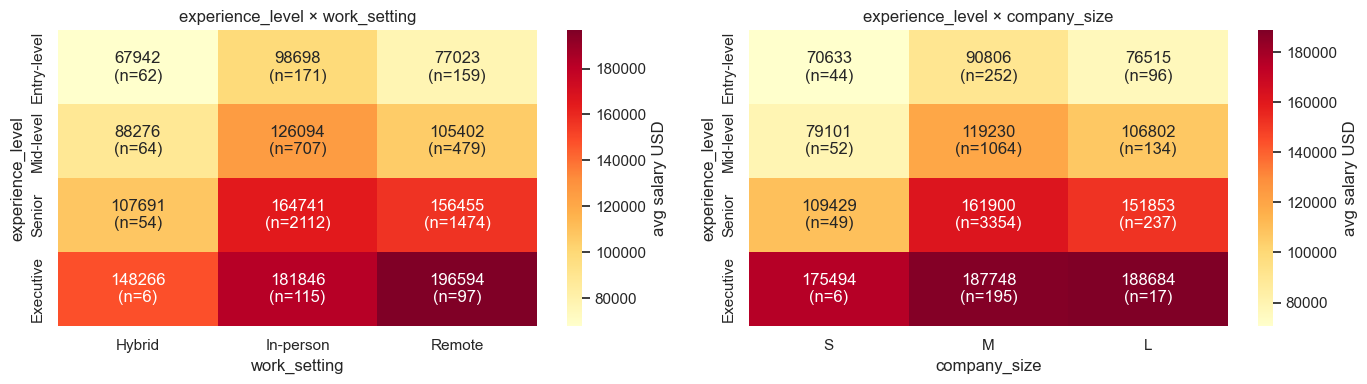

In [11]:
def pivot_pair(row, col, row_order=None, col_order=None):
    mean_pv = df.pivot_table('salary_in_usd', index=row, columns=col, aggfunc='mean')
    n_pv    = df.pivot_table('salary_in_usd', index=row, columns=col, aggfunc='count')
    if row_order:
        mean_pv = mean_pv.reindex(row_order); n_pv = n_pv.reindex(row_order)
    if col_order:
        mean_pv = mean_pv[col_order]; n_pv = n_pv[col_order]
    return mean_pv, n_pv

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (r, c, ro, co) in zip(
    axes,
    [('experience_level', 'work_setting', EXP_ORDER, None),
     ('experience_level', 'company_size', EXP_ORDER, SIZE_ORDER)],
):
    mean_pv, n_pv = pivot_pair(r, c, ro, co)
    annot = mean_pv.round(0).astype('Int64').astype(str) + '\n(n=' + n_pv.fillna(0).astype(int).astype(str) + ')'
    sns.heatmap(mean_pv, annot=annot, fmt='', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'avg salary USD'})
    ax.set_title(f'{r} × {c}')
plt.tight_layout(); plt.show()

## 7. Year × experience trend

**Câu hỏi mục tiêu**: salary có growth theo năm không? Growth có khác giữa các cấp seniority không?

**Công cụ**: line plot với `hue = experience_level`, marker = mean per (year, exp). Bảng pivot bổ sung số chính xác.

**Lý do chọn line plot, không bar**:
- `work_year` mang tính **ordinal continuous-like** (2020 → 2023). Line truyền tải trend tốt hơn bar discrete.
- `hue` cho phép so sánh 4 ladder song song trên cùng 1 plot — bar dùng cho cùng mục đích sẽ overplot.

**Cách đọc**:
- Slope của mỗi line → growth rate per năm.
- Khoảng cách giữa các line → gap giữa seniority levels.
- Lines song song → ladder consistent qua các năm.
- Lines crossing → có inversion (cấp dưới vượt cấp trên năm nào đó) — bất thường.

**Hạn chế**:
- Dataset chỉ 4 năm → line ngắn, không đủ để forecast. Chủ yếu confirm/refute "experience gap consistent qua các năm".
- Bias năm (mục 3): 75% rows ở 2023 → trend các năm trước có ít sample, slope đầu line đáng nghi ngờ.

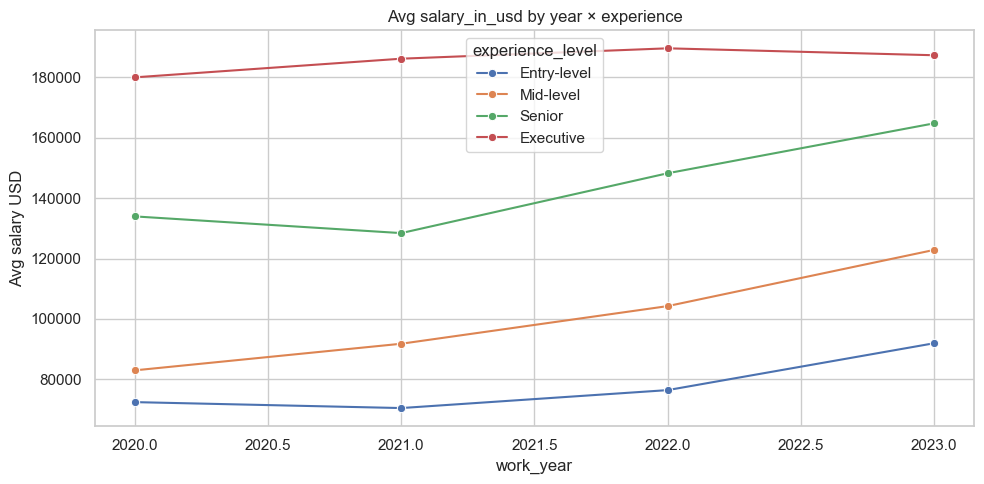

experience_level,Entry-level,Mid-level,Senior,Executive
work_year,,,,
2020,72477.0,82993.0,133937.0,179958.0
2021,70512.0,91798.0,128411.0,186128.0
2022,76451.0,104252.0,148215.0,189562.0
2023,91957.0,122841.0,164730.0,187271.0


In [12]:
trend = df.groupby(['work_year', 'experience_level'], observed=True)['salary_in_usd'].agg(['mean', 'count']).reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x='work_year', y='mean', hue='experience_level', hue_order=EXP_ORDER, marker='o')
plt.title('Avg salary_in_usd by year × experience')
plt.ylabel('Avg salary USD')
plt.tight_layout(); plt.show()

trend.pivot(index='work_year', columns='experience_level', values='mean').round(0).reindex(columns=EXP_ORDER)

## 8. Geographic — top countries by salary

**Câu hỏi mục tiêu**: country nào trả lương cao nhất? `company_country` (nơi trả) và `employee_country` (nơi nhân viên ở) có khác nhau không?

**Công cụ**: bar plot top-15 country, sort theo **median** salary, lọc `n ≥ 30`. Bảng số đi kèm.

**Lý do**:
- **min_n=30**: country chỉ có 1-2 rows → mean unstable. 30 là rule of thumb cho **CLT** (sampling distribution của mean approximate normal). Có thể nâng lên nếu muốn ranking robust hơn, đánh đổi là cắt nhiều country.
- **Sort median, không mean**: cùng lý do mục 4 — robust với outlier.
- **Top 15**: viewable trên 1 chart không cuộn; chú trọng head distribution chứ không phải tail.
- **2 charts (company + employee)**: salary thường tính theo company location, nhưng employee residence quyết định cost-of-living thực tế. Mismatch giữa 2 chart → có cross-border activity (mục 9 xác nhận bằng số).

**Cách đọc**: rank cao nhất + so 2 chart cạnh nhau. Country chỉ xuất hiện ở 1 bên → có thể là tax-haven (company HQ) hoặc destination-only (residence-only).

**Hạn chế (liên kết mục 3 bias)**:
- US chiếm 80% dataset → ranking các country khác có ít sample, ranking có thể đảo vị trí dễ.
- Bar plot **không hiển thị CI**. Country n=30 vẫn có CI rộng. Enhancement đề xuất: bootstrap 95% CI cho median per country.
- Median = robust nhưng vẫn là 1 point estimate; spread không thể hiện.
- **Map visualization** để Power BI lo (filled map qua Bing/ArcGIS) — pandas/seaborn không có tooling phù hợp.

In [ ]:
MIN_N = 30

for col, title in [('company_country',  'Salary by company country'),
                   ('employee_country', 'Salary by employee residence')]:
    s = df.groupby(col, observed=True)['salary_in_usd'].agg(['mean', 'median', 'count'])
    s = s[s['count'] >= MIN_N].sort_values('median', ascending=False).head(15)
    plt.figure(figsize=(9, 5))
    sns.barplot(y=s.index, x=s['median'], hue=s.index,
                palette='crest', legend=False)
    plt.title(f'{title}  (top 15, n≥{MIN_N})')
    plt.xlabel('median salary USD')
    plt.tight_layout(); plt.show()
    display(s.round(0))

## 9. Business slice: cross-border employment

**Câu hỏi mục tiêu**: tỉ lệ posting có `employee_country` ≠ `company_country`? Trong số đó có bao nhiêu là Remote?

**Công cụ**: descriptive statistics — filter + groupby. Không cần test thống kê vì câu hỏi là **mô tả nghiệp vụ**, không inferential.

**Lý do quan tâm**:
- Confirm/refute narrative "Remote enables global hiring" bằng số định lượng.
- Cross-border employment liên quan trực tiếp đến tax, compliance, payroll — có giá trị business.

**Cách đọc**:
- `% of all rows` → mức độ phổ biến của cross-border.
- `pct_of_all_cross` per work_setting → trong số cross-border, hình thức nào chiếm chủ đạo.

**Limitation**: dataset chỉ có country, không có city/state level. Một số cross-border thực tế (vd. nội bang trong US) có thể bị miss vì cùng country.

In [14]:
cross = df[df['employee_country'] != df['company_country']]
print(f'Cross-border postings: {len(cross):,} / {len(df):,} ({len(cross)/len(df)*100:.1f}%)')
by_setting = cross.groupby('work_setting', observed=True).size().to_frame('n')
by_setting['pct_of_all_cross'] = (by_setting['n'] / by_setting['n'].sum() * 100).round(1)
by_setting

Cross-border postings: 117 / 5,500 (2.1%)


,n,pct_of_all_cross
work_setting,,
Hybrid,17,14.5
In-person,10,8.5
Remote,90,76.9


## 10. Numeric correlation — Pearson vs Spearman

**Câu hỏi mục tiêu**: các biến số (numeric) liên quan với nhau như thế nào? Quan hệ tuyến tính hay chỉ monotonic?

**Công cụ**: 2 correlation matrix đặt cạnh nhau (Pearson + Spearman), heatmap `coolwarm` center=0.

| Metric | Đo gì | Khi nào dùng |
|---|---|---|
| Pearson | Linear relationship | Quan hệ thẳng, ít outlier |
| Spearman | Monotonic (không cần linear) | Robust với outlier, ordinal data, quan hệ cong |

**Lý do show CẢ HAI**:
- So sánh 2 matrix có thể spot **inconsistency**:
  - Pearson < Spearman → quan hệ phi tuyến (vd. log-linear curve).
  - Pearson > Spearman → outlier kéo Pearson lên giả tạo.
- Spearman tốt cho `experience_rank ↔ salary` vì experience là ordinal 4-value.

**Cách đọc**:
- Diagonal = 1 (correlation với chính nó).
- Off-diagonal màu đậm = correlation mạnh; trắng = ~0.
- Cell red (+) = positive, blue (−) = negative.

**Hạn chế**:
- **Numeric cols rất ít** trong dataset (chỉ `work_year`, `experience_rank`, `salary`, `salary_in_usd`).
- `salary` raw trong nhiều currency → tương quan yếu với `salary_in_usd` là expected (sau khi normalize).
- Phần này giá trị giới hạn so với categorical analysis (mục 4–5).

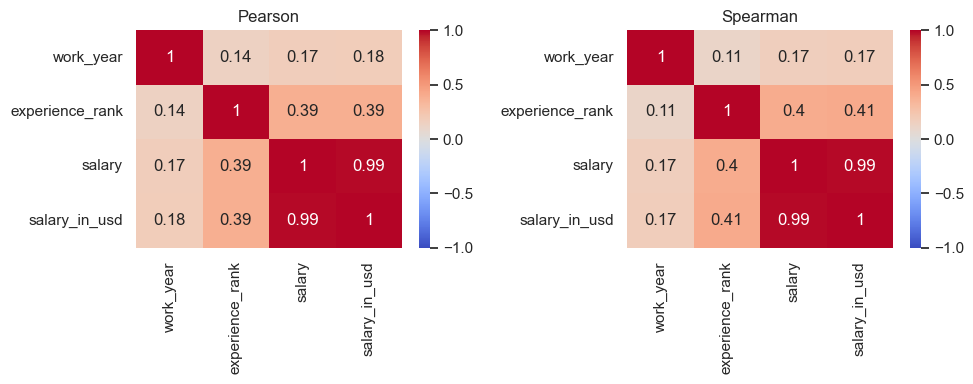

In [15]:
num = df[['work_year', 'experience_rank', 'salary', 'salary_in_usd']].copy()
corr_pearson  = num.corr(method='pearson').round(3)
corr_spearman = num.corr(method='spearman').round(3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(corr_pearson,  annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson')
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman')
plt.tight_layout(); plt.show()

In [16]:
print('=== KEY TAKEAWAYS ===\n')

print('Top 3 dims by omega² (cardinality-adjusted variance explained):')
for _, r in ranking.head(3).iterrows():
    print(f'  - {r["dim"]:<22} omega² = {r["omega_squared"]:.3f}   (n_groups={r["n_groups"]})')

print('\nTop 3 dims by F-stat per df (per-group separation — cleanest signal):')
for _, r in ranking.sort_values("F_per_df", ascending=False).head(3).iterrows():
    print(f'  - {r["dim"]:<22} F/df  = {r["F_per_df"]:.1f}   (n_groups={r["n_groups"]})')

print(f'\nMonotonic correlation (Spearman) experience_rank ↔ salary_in_usd: {corr_spearman.loc["experience_rank", "salary_in_usd"]:+.3f}')
print(f'Distribution skew (salary_in_usd): {df["salary_in_usd"].skew():+.3f}  (mild right-skew; linear scale OK)')
print(f'Cross-border postings: {(df["employee_country"] != df["company_country"]).mean()*100:.1f}% of rows')
print(f'Median salary (USD): {df["salary_in_usd"].median():,.0f}   |   Mean: {df["salary_in_usd"].mean():,.0f}')

print('\nCaveats:')
print('  - Geo dims (country / continent / currency) are collinear → cumulative attribution overstated.')
print('  - employment_type omega² ≈ 0 because ~99% of rows are Full-time (unbalanced groups).')

=== KEY TAKEAWAYS ===

Top 3 dims by omega² (cardinality-adjusted variance explained):
  - job_title              omega² = 0.163   (n_groups=111)
  - employee_country       omega² = 0.158   (n_groups=55)
  - experience_level       omega² = 0.153   (n_groups=4)

Top 3 dims by F-stat per df (per-group separation — cleanest signal):
  - experience_level       F/df  = 110.7   (n_groups=4)
  - work_setting           F/df  = 46.9   (n_groups=3)
  - company_size           F/df  = 43.5   (n_groups=3)

Monotonic correlation (Spearman) experience_rank ↔ salary_in_usd: +0.409
Distribution skew (salary_in_usd): +0.651  (mild right-skew; linear scale OK)
Cross-border postings: 2.1% of rows
Median salary (USD): 140,000   |   Mean: 146,156

Caveats:
  - Geo dims (country / continent / currency) are collinear → cumulative attribution overstated.
  - employment_type omega² ≈ 0 because ~99% of rows are Full-time (unbalanced groups).


## Tổng kết

### Pyramid logic — vì sao thứ tự này tối ưu

```
mục 2  Distribution         → biết measure có cần transform không
mục 3  Category balance     → bias check trước per-dim → flag dim/group không đáng tin
mục 4  Per-dim univariate   → bức tranh từng group, mỗi chiều
mục 5  Effect ranking       → key drivers (omega² + F/df)
mục 5b Tukey HSD post-hoc   → đi sâu vào driver mạnh nhất, confirm pairwise
mục 6  Cross-dim heatmap    → tìm interaction effect (visual)
mục 7  Year trend           → temporal axis
mục 8  Geographic top-N     → country deep-dive
mục 9  Cross-border slice   → câu hỏi business cụ thể
mục 10 Numeric correlation  → bổ sung cho numeric cols ít ỏi
```

Mỗi tầng chỉ làm khi tầng dưới hợp lệ. Cell `summary` output chính các con số rút ra từ chuỗi này.

### Cảnh báo bias rút ra từ mục 3

| Dim | Bias | Hệ quả với analysis |
|---|---|---|
| `employment_type` | 99% Full-time | omega² ≈ 0 không nghĩa "không quan trọng" — không đủ sample để phân biệt |
| `salary_currency` / `country` | 80%+ US/USD | Geographic ranking ngoài top-5 có CI rất rộng |
| `company_size` | 88% Medium | Comparison S vs L có ít sample, kết luận tentative |
| `work_year` | 75% 2023 | Trend các năm trước slope không đáng tin |
| `work_setting` | 57% In-person | Cân bằng nhất trong các chiều structural |

Khi present trên Power BI, cần ưu tiên **slicer trên dim balanced** và discount các slice mà sample nhỏ.

## References
- https://easystats.github.io/effectsize/reference/eta_squared.html
- https://youtu.be/xhB-dmKmzRk?si=2ll0lt8OsyQb5jiT
- https://youtu.be/iGUqad1eNtQ?si=dXCDY2JihcICBxEL